In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load Breast Cancer Dataset
data = load_breast_cancer()
X = data.data
y = data.target   # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("Classes:", data.target_names)
print("Class distribution  0 (malignant):", np.sum(y==0), "  1 (benign):", np.sum(y==1))

# Standardize features so gradient descent converges properly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution  0 (malignant): 212   1 (benign): 357
Training samples: 455
Test samples    : 114


In [3]:
# Manual Logistic Regression using NumPy

class LogisticRegressionManual:
    def __init__(self, learning_rate=0.1, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        # Clip z to prevent overflow in exp()
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def compute_loss(self, y_true, y_pred):
        # Binary Cross-Entropy Log-Loss formula
        # L = -1/N * sum( y*log(p) + (1-y)*log(1-p) )
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)   # initialize all weights to 0
        self.bias = 0.0

        for epoch in range(self.epochs):
            # Step 1: Linear combination z = X.w + b
            z = np.dot(X, self.weights) + self.bias

            # Step 2: Sigmoid activation -> predicted probabilities
            y_pred = self.sigmoid(z)

            # Step 3: Compute log-loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # Step 4: Compute gradients
            error = y_pred - y
            dw = np.dot(X.T, error) / n_samples   # dL/dw
            db = np.mean(error)                    # dL/db

            # Step 5: Gradient descent weight update
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            if (epoch + 1) % 200 == 0:
                print(f"  Epoch {epoch+1:>4d}  |  Loss: {loss:.6f}")

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("Training Manual Logistic Regression...")
print("-" * 45)
manual_model = LogisticRegressionManual(learning_rate=0.1, epochs=1000)
manual_model.fit(X_train, y_train)

y_pred_manual = manual_model.predict(X_test)
acc_manual = accuracy_score(y_test, y_pred_manual)
print(f"\nManual Model Test Accuracy: {acc_manual * 100:.2f}%")

Training Manual Logistic Regression...
---------------------------------------------
  Epoch  200  |  Loss: 0.087067
  Epoch  400  |  Loss: 0.073658
  Epoch  600  |  Loss: 0.067550
  Epoch  800  |  Loss: 0.063781
  Epoch 1000  |  Loss: 0.061132

Manual Model Test Accuracy: 98.25%


In [4]:
# sklearn Logistic Regression

sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train, y_train)

y_pred_sklearn = sklearn_model.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"sklearn Model Test Accuracy: {acc_sklearn * 100:.2f}%")

sklearn Model Test Accuracy: 97.37%


In [5]:
# Side-by-side Weight Comparison (first 10 features)

feature_names = data.feature_names
manual_w  = manual_model.weights
sklearn_w = sklearn_model.coef_[0]

print(f"{'Feature':<35} {'Manual Weight':>15} {'sklearn Weight':>15} {'Difference':>12}")
print("-" * 80)
for i in range(10):
    diff = manual_w[i] - sklearn_w[i]
    print(f"{feature_names[i]:<35} {manual_w[i]:>15.6f} {sklearn_w[i]:>15.6f} {diff:>12.6f}")

print("\nNote: Difference exists because sklearn uses L2 regularization (C=1.0) by default.")
print(f"Manual Bias : {manual_model.bias:.6f}")
print(f"sklearn Bias: {sklearn_model.intercept_[0]:.6f}")

Feature                               Manual Weight  sklearn Weight   Difference
--------------------------------------------------------------------------------
mean radius                               -0.546371       -0.434647    -0.111724
mean texture                              -0.657830       -0.397194    -0.260636
mean perimeter                            -0.524147       -0.396070    -0.128077
mean area                                 -0.578028       -0.469990    -0.108037
mean smoothness                           -0.202302       -0.067394    -0.134907
mean compactness                           0.161363        0.526717    -0.365353
mean concavity                            -0.632986       -0.807676     0.174690
mean concave points                       -0.768760       -1.107711     0.338951
mean symmetry                              0.041697        0.241538    -0.199841
mean fractal dimension                     0.307213        0.078447     0.228766

Note: Difference exists bec

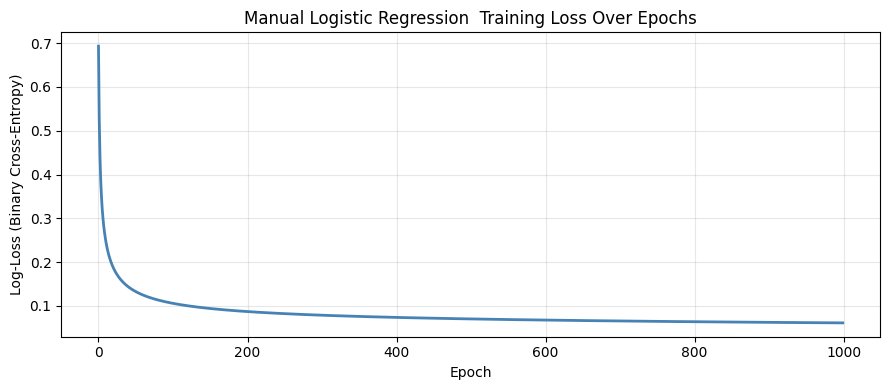

Loss curve saved.


In [6]:
# Training Loss Curve

plt.figure(figsize=(9, 4))
plt.plot(manual_model.loss_history, color='steelblue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Log-Loss (Binary Cross-Entropy)")
plt.title("Manual Logistic Regression  Training Loss Over Epochs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=130, bbox_inches='tight')
plt.show()
print("Loss curve saved.")

  Epoch  200  |  Loss: 0.292814
  Epoch  400  |  Loss: 0.275922
  Epoch  600  |  Loss: 0.271278
  Epoch  800  |  Loss: 0.269524
  Epoch 1000  |  Loss: 0.268764


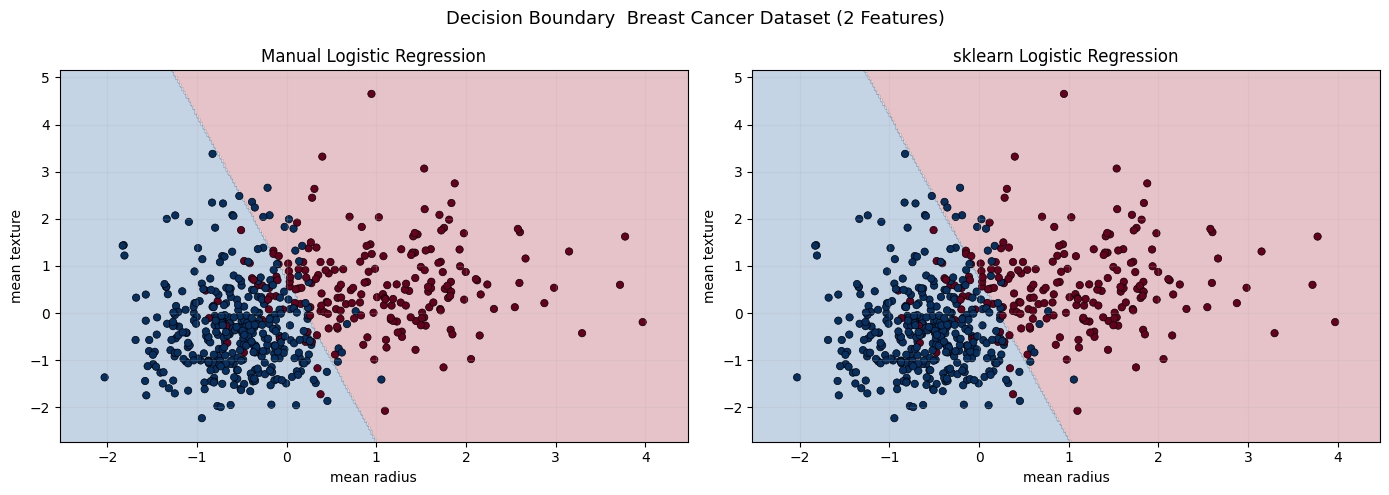

Decision boundary plot saved.


In [7]:
# Decision Boundary using 2 Features
# Feature 0 = mean radius  |  Feature 1 = mean texture

feat_idx = [0, 1]
feature_labels = [data.feature_names[i] for i in feat_idx]

X_2d = X_scaled[:, feat_idx]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# Train both models on 2 features
manual_2d = LogisticRegressionManual(learning_rate=0.1, epochs=1000)
manual_2d.fit(X_train_2d, y_train_2d)

sklearn_2d = LogisticRegression(max_iter=1000, random_state=42)
sklearn_2d.fit(X_train_2d, y_train_2d)

# Mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_manual  = manual_2d.predict(grid).reshape(xx.shape)
Z_sklearn = sklearn_2d.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Manual Logistic Regression", "sklearn Logistic Regression"]

for ax, Z, title in zip(axes, [Z_manual, Z_sklearn], titles):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='RdBu',
               edgecolors='k', s=28, linewidths=0.5)
    ax.set_xlabel(feature_labels[0])
    ax.set_ylabel(feature_labels[1])
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

plt.suptitle("Decision Boundary  Breast Cancer Dataset (2 Features)", fontsize=13)
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=130, bbox_inches='tight')
plt.show()
print("Decision boundary plot saved.")

## Part 2: Multiclass Classification — Iris Dataset with OvR Strategy

In [8]:
# Iris Dataset  OvR Multiclass Logistic Regression
# Using OneVsRestClassifier to explicitly apply OvR strategy

from sklearn.multiclass import OneVsRestClassifier

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Iris Dataset shape:", X_iris.shape)
print("Classes:", iris.target_names)
print("Samples per class:", np.bincount(y_iris))

scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris_scaled, y_iris, test_size=0.2, random_state=42
)

# OvR = One vs Rest: trains one binary classifier per class
# Class 0 vs {1,2}, Class 1 vs {0,2}, Class 2 vs {0,1}
# OneVsRestClassifier wraps any binary classifier for multiclass
ovr_model = OneVsRestClassifier(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
)
ovr_model.fit(X_tr, y_tr)

y_pred_iris = ovr_model.predict(X_te)
acc_iris = accuracy_score(y_te, y_pred_iris)
print(f"\nIris OvR Model Test Accuracy: {acc_iris * 100:.2f}%")

Iris Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Samples per class: [50 50 50]

Iris OvR Model Test Accuracy: 96.67%


In [9]:
# predict_proba() Output  first 15 test samples

proba = ovr_model.predict_proba(X_te)

print(f"{'#':<5} {'True Label':<15} {'Pred Label':<20} {'P(setosa)':>11} {'P(versicolor)':>14} {'P(virginica)':>13}")
print("-" * 82)
for i in range(15):
    true_cls = iris.target_names[y_te[i]]
    pred_cls = iris.target_names[y_pred_iris[i]]
    status   = "OK" if y_te[i] == y_pred_iris[i] else "WRONG"
    print(f"{i+1:<5} {true_cls:<15} {pred_cls + '  ' + status:<20} "
          f"{proba[i][0]:>11.4f} {proba[i][1]:>14.4f} {proba[i][2]:>13.4f}")

print("\nNote: Each row sums to 1.0 (probability distribution over 3 classes).")
print(f"Row 0 probability sum: {proba[0].sum():.6f}")

#     True Label      Pred Label             P(setosa)  P(versicolor)  P(virginica)
----------------------------------------------------------------------------------
1     versicolor      versicolor  OK            0.0185         0.7947        0.1868
2     setosa          setosa  OK                0.9456         0.0543        0.0000
3     virginica       virginica  OK             0.0000         0.4184        0.5816
4     versicolor      versicolor  OK            0.0199         0.6153        0.3648
5     versicolor      versicolor  OK            0.0038         0.6539        0.3423
6     setosa          setosa  OK                0.8812         0.1188        0.0000
7     versicolor      versicolor  OK            0.1535         0.7620        0.0845
8     virginica       virginica  OK             0.0007         0.1847        0.8146
9     versicolor      versicolor  OK            0.0012         0.6397        0.3592
10    versicolor      versicolor  OK            0.0480         0.8667        

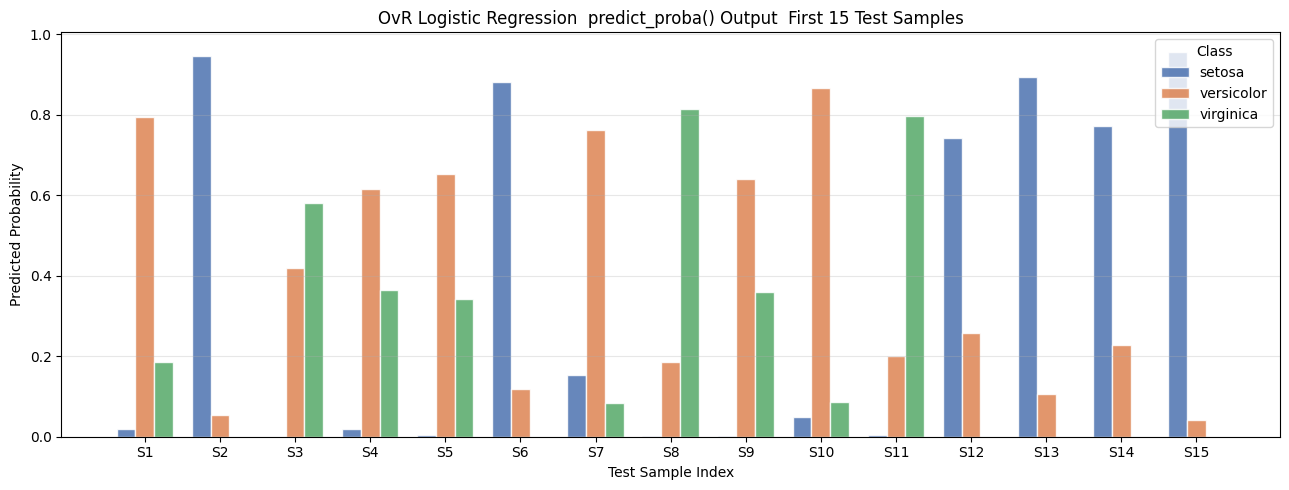

Probability plot saved.


In [10]:
# Probability Distribution Bar Chart  first 15 test samples

samples = np.arange(15)
width   = 0.25
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 5))
for i, cls_name in enumerate(iris.target_names):
    ax.bar(samples + i * width, proba[:15, i], width,
           label=cls_name, color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Predicted Probability")
ax.set_title("OvR Logistic Regression  predict_proba() Output  First 15 Test Samples")
ax.set_xticks(samples + width)
ax.set_xticklabels([f"S{i+1}" for i in range(15)])
ax.legend(title="Class")
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("iris_proba.png", dpi=130, bbox_inches='tight')
plt.show()
print("Probability plot saved.")

In [11]:
# Final Summary

print("=" * 55)
print("            RESULTS SUMMARY")
print("=" * 55)
print(f"  Manual  LR  Breast Cancer  : {acc_manual*100:.2f}%")
print(f"  sklearn LR  Breast Cancer  : {acc_sklearn*100:.2f}%")
print(f"  OvR     LR  Iris           : {acc_iris*100:.2f}%")
print("=" * 55)
print("  Plots generated:")
print("  1. loss_curve.png")
print("  2. decision_boundary.png")
print("  3. iris_proba.png")
print("=" * 55)

            RESULTS SUMMARY
  Manual  LR  Breast Cancer  : 98.25%
  sklearn LR  Breast Cancer  : 97.37%
  OvR     LR  Iris           : 96.67%
  Plots generated:
  1. loss_curve.png
  2. decision_boundary.png
  3. iris_proba.png
